In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
dataset = pd.read_csv("Bengaluru_House_Data.csv")

dataset.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [3]:
dataset = dataset.drop('society', axis=1)

In [4]:
dataset = dataset.dropna()

In [5]:
dataset.isnull().sum()

area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [6]:
dataset['bhk'] = dataset['size'].astype(str).str.split().str[0]
dataset['bhk'] = pd.to_numeric(dataset['bhk'], errors='coerce')

dataset = dataset.dropna(subset=['bhk'])

dataset['bhk'] = dataset['bhk'].astype(int)

dataset = dataset.drop('size', axis=1)

In [7]:
def convert_sqft(x):
    tokens = str(x).split('-')
    if len(tokens) == 2:
        return (float(tokens[0]) + float(tokens[1])) / 2
    try:
        return float(x)
    except:
        return None

dataset['total_sqft'] = dataset['total_sqft'].apply(convert_sqft)

dataset = dataset.dropna()

In [8]:
dataset['location'] = dataset['location'].astype(str).str.strip()

In [9]:
location_stats = dataset['location'].value_counts()

dataset['location'] = dataset['location'].apply(
    lambda x: 'other' if location_stats.get(x,0) <= 10 else x
)

In [10]:
dataset = dataset[dataset.bhk > 0]

dataset = dataset[dataset.total_sqft / dataset.bhk > 300]

In [11]:
dataset = pd.get_dummies(dataset, drop_first=True)

In [12]:
X = dataset.drop('price', axis=1)
y = dataset['price']

In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [34]:
import pickle

pickle.dump(scaler, open("scaler.pkl", "wb"))

In [36]:
pickle.dump(X.columns.tolist(), open("columns.pkl","wb"))

In [35]:
dataset


,total_sqft,bath,balcony,price,bhk,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,availability_14-Nov,availability_15-Aug,...,location_Vishveshwarya Layout,location_Vishwapriya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,1056.0,2.0,1.0,39.07,2,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2600.0,5.0,3.0,120.00,4,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1440.0,2.0,3.0,62.00,3,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1521.0,3.0,1.0,95.00,3,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1200.0,2.0,1.0,51.00,2,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13314,1715.0,3.0,3.0,112.00,3,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
13315,3453.0,4.0,0.0,231.00,5,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
13317,1141.0,2.0,1.0,60.00,2,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
13318,4689.0,4.0,1.0,488.00,4,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [14]:
model = LinearRegression()

model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
pred = model.predict(x_test)

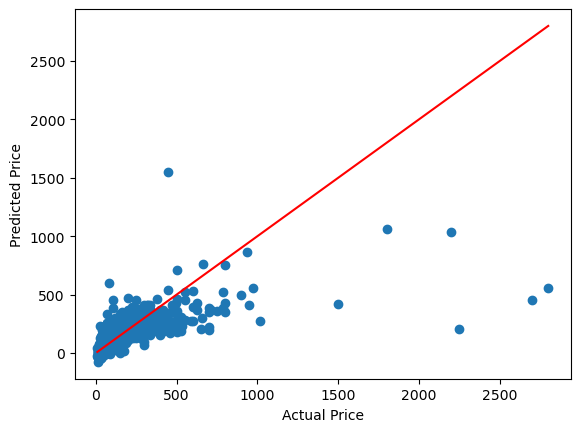

In [16]:
plt.scatter(y_test, pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()

In [17]:
residuals = y_test - pred

In [18]:
residuals

9240     -517.917654
1008       37.030965
4394       22.786986
11026      18.729058
3180     2246.356815
            ...     
6405      -14.688147
5578       72.032815
10596      43.358586
12984      23.535830
8948     -115.971348
Name: price, Length: 2370, dtype: float64

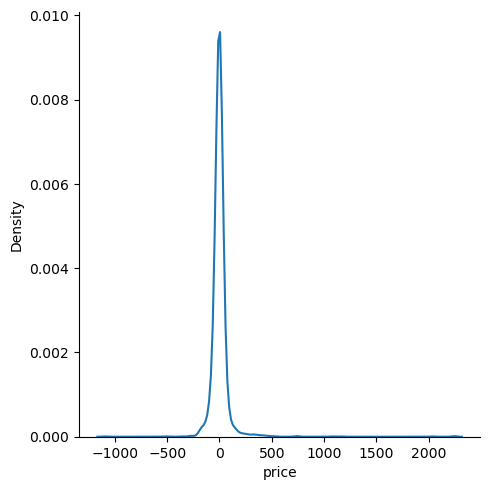

In [19]:
sns.displot(residuals,kind="kde")

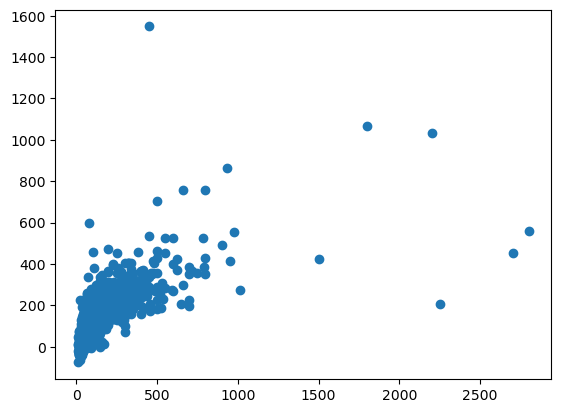

In [20]:
plt.scatter(y_test,pred)

In [21]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_absolute_error(y_test,pred))
print(mean_squared_error(y_test,pred))
print(np.sqrt(mean_squared_error(y_test,pred))) #root mean squred error

40.534665986086054
11959.194638928982
109.35810275845581


In [22]:
# R^2 and adjusted R^2
from sklearn.metrics import r2_score
score = r2_score(y_test,pred)

In [23]:
score

0.47974284760500496

In [24]:
#adjusted is always lessthan R^2
score1 = 1 - (1-score)*(len(y_test-1))/(len(y_test)-x_test.shape[1]-1)

In [25]:
score1

0.3985319750360301

**New Data Prediction**

In [26]:
X.iloc[[0]].to_numpy()

array([[1056.0, 2.0, 1.0, 2, False, False, True, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, True, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        

In [27]:
model.predict([X.iloc[0]])

c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([np.float64(59.71190774776416)], dtype=object)

In [28]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [29]:
scaler.fit_transform(X.iloc[[0]].to_numpy())

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [30]:
model.predict(scaler.fit_transform(X.iloc[[0]].to_numpy()))

c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([30.07185039])

**Pickle the file for deployment**

In [31]:
import pickle

In [32]:
pickle.dump(model,open("regmodel.pkl","wb"))

In [61]:
pickled_model = pickle.load(open("regmodel.pkl","rb")) # always use rb when loading

In [62]:
pickled_model.predict(scaler.fit_transform(X.iloc[[0]].to_numpy()))

c:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([30.07185039])